Conectar con google drive para poder tener acceso a los datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
path = '/content/drive/MyDrive/TFG/Data_prueba/esgcclbp'

In [ ]:
print(os.listdir(path))


['bp1dia.txt', 'bp1min.txt', 'cl1dia.txt', 'es1dia.txt', 'cl1min.txt', 'gc1dia.txt', 'es1min.txt', 'gc1min.txt']


Importar ES, min y día para sacar parámetros y extraer información



In [ ]:
df_es1min = pd.read_csv(path+'/es1min.txt')
print(df_es1min.head(), len(df_es1min))

  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>   <OPEN>   <HIGH>    <LOW>  <CLOSE>  \
0       ES     I      20151209   70100  2063.00  2063.25  2063.00  2063.25   
1       ES     I      20151209   70200  2063.25  2063.50  2063.00  2063.50   
2       ES     I      20151209   70300  2063.25  2063.50  2063.25  2063.50   
3       ES     I      20151209   70400  2063.50  2063.50  2063.25  2063.50   
4       ES     I      20151209   70500  2063.25  2063.50  2063.25  2063.50   

   <VOL>  <OPENINT>  
0     60          0  
1     37          0  
2     26          0  
3     11          0  
4      6          0   2579332


In [ ]:
df_es1dia = pd.read_csv(path+'/es1dia.txt')
print(df_es1dia.head(), len(df_es1dia))

  <TICKER> <PER>  <DTYYYYMMDD>  <TIME>  <OPEN>  <HIGH>   <LOW>  <CLOSE>  \
0       ES     D      19970911       0  918.75  929.75  910.25   916.00   
1       ES     D      19970912       0  918.00  936.50  913.50   918.75   
2       ES     D      19970915       0  933.50  939.75  929.00   931.25   
3       ES     D      19970916       0  931.25  960.00  930.25   956.00   
4       ES     D      19970917       0  956.00  962.50  951.50   956.00   

   <VOL>  <OPENINT>  
0  11825       2909  
1   9759       4059  
2   8551       3818  
3  11749       5314  
4  10849       5516   6601


In [ ]:
df_es1min.columns = df_es1min.columns.str.replace(r"[<>]", "", regex=True).str.upper()
df_es1min['datetime'] = pd.to_datetime(
    df_es1min['DTYYYYMMDD'].astype(str) + df_es1min['TIME'].astype(str).str.zfill(6),
    format='%Y%m%d%H%M%S'
)
df_es1min = df_es1min.sort_values('datetime')
df_es1min = df_es1min.drop(columns=['DTYYYYMMDD'])
df_es1min = df_es1min.dropna()

df_es1min["datetime"] = pd.to_datetime(df_es1min["datetime"])
df_es1min.set_index("datetime")

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT
datetime,,,,,,,,,
2015-12-09 07:01:00,ES,I,70100,2063.00,2063.25,2063.00,2063.25,60,0
2015-12-09 07:02:00,ES,I,70200,2063.25,2063.50,2063.00,2063.50,37,0
2015-12-09 07:03:00,ES,I,70300,2063.25,2063.50,2063.25,2063.50,26,0
2015-12-09 07:04:00,ES,I,70400,2063.50,2063.50,2063.25,2063.50,11,0
2015-12-09 07:05:00,ES,I,70500,2063.25,2063.50,2063.25,2063.50,6,0
...,...,...,...,...,...,...,...,...,...
2023-09-20 11:38:00,ES,I,113800,4497.00,4497.25,4497.00,4497.25,149,0
2023-09-20 11:39:00,ES,I,113900,4497.25,4498.00,4497.25,4497.50,145,0
2023-09-20 11:40:00,ES,I,114000,4497.50,4497.50,4497.00,4497.00,95,0


In [ ]:
df_es1dia.columns = df_es1dia.columns.str.replace(r"[<>]", "", regex=True).str.upper()
df_es1dia['datetime'] = pd.to_datetime(
    df_es1dia['DTYYYYMMDD'].astype(str) + df_es1dia['TIME'].astype(str).str.zfill(6),
    format='%Y%m%d%H%M%S'
)
df_es1dia = df_es1dia.sort_values('datetime')
df_es1dia = df_es1dia.drop(columns=['DTYYYYMMDD'])
df_es1dia = df_es1dia.dropna()

df_es1dia["datetime"] = pd.to_datetime(df_es1dia["datetime"])
df_es1dia.set_index("datetime")

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT
datetime,,,,,,,,,
1997-09-11,ES,D,0,918.75,929.75,910.25,916.00,11825,2909
1997-09-12,ES,D,0,918.00,936.50,913.50,918.75,9759,4059
1997-09-15,ES,D,0,933.50,939.75,929.00,931.25,8551,3818
1997-09-16,ES,D,0,931.25,960.00,930.25,956.00,11749,5314
1997-09-17,ES,D,0,956.00,962.50,951.50,956.00,10849,5516
...,...,...,...,...,...,...,...,...,...
2023-09-14,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081
2023-09-15,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081
2023-09-18,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081


In [ ]:
df_es1min

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime
0,ES,I,70100,2063.00,2063.25,2063.00,2063.25,60,0,2015-12-09 07:01:00
1,ES,I,70200,2063.25,2063.50,2063.00,2063.50,37,0,2015-12-09 07:02:00
2,ES,I,70300,2063.25,2063.50,2063.25,2063.50,26,0,2015-12-09 07:03:00
3,ES,I,70400,2063.50,2063.50,2063.25,2063.50,11,0,2015-12-09 07:04:00
4,ES,I,70500,2063.25,2063.50,2063.25,2063.50,6,0,2015-12-09 07:05:00
...,...,...,...,...,...,...,...,...,...,...
2579327,ES,I,113800,4497.00,4497.25,4497.00,4497.25,149,0,2023-09-20 11:38:00
2579328,ES,I,113900,4497.25,4498.00,4497.25,4497.50,145,0,2023-09-20 11:39:00
2579329,ES,I,114000,4497.50,4497.50,4497.00,4497.00,95,0,2023-09-20 11:40:00
2579330,ES,I,114100,4497.25,4497.50,4497.00,4497.25,159,0,2023-09-20 11:41:00


In [ ]:
df_es1dia

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime
0,ES,D,0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11
1,ES,D,0,918.00,936.50,913.50,918.75,9759,4059,1997-09-12
2,ES,D,0,933.50,939.75,929.00,931.25,8551,3818,1997-09-15
3,ES,D,0,931.25,960.00,930.25,956.00,11749,5314,1997-09-16
4,ES,D,0,956.00,962.50,951.50,956.00,10849,5516,1997-09-17
...,...,...,...,...,...,...,...,...,...,...
6596,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081,2023-09-14
6597,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081,2023-09-15
6598,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081,2023-09-18
6599,ES,D,0,4503.25,4509.50,4462.25,4492.00,1369869,2229081,2023-09-19


# Crear variables

Definimos la función displ= ((high+low)/2)- open  Para el día. Para ello guardamos los máximos, mínimos y de apertura en vectoeres.

In [ ]:
high = df_es1dia['HIGH']
low = df_es1dia['LOW']
open = df_es1dia['OPEN']

In [ ]:
def displ(high, low, open):
  return ((high+low)/2)- open
display = displ(high, low, open)
df_es1dia['DISPLAY'] = display
df_es1dia

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime,DISPLAY
0,ES,D,0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11,1.250
1,ES,D,0,918.00,936.50,913.50,918.75,9759,4059,1997-09-12,7.000
2,ES,D,0,933.50,939.75,929.00,931.25,8551,3818,1997-09-15,0.875
3,ES,D,0,931.25,960.00,930.25,956.00,11749,5314,1997-09-16,13.875
4,ES,D,0,956.00,962.50,951.50,956.00,10849,5516,1997-09-17,1.000
...,...,...,...,...,...,...,...,...,...,...,...
6596,ES,D,0,4521.25,4562.00,4519.00,4557.75,1600931,2229081,2023-09-14,19.250
6597,ES,D,0,4556.50,4566.00,4494.00,4499.00,1708046,2229081,2023-09-15,-26.500
6598,ES,D,0,4499.50,4514.50,4487.00,4502.50,1113375,2229081,2023-09-18,1.250
6599,ES,D,0,4503.25,4509.50,4462.25,4492.00,1369869,2229081,2023-09-19,-17.375


Ahora se va a determinar BULLISH (es un valor que depende de displ, en caso de que displ sea positivo implica que  es verdadero, si es falso es que es negativo)

In [ ]:
df_es1dia['BULLISH'] = df_es1dia['DISPLAY'] > 0


Definición del set de predictor en base a días anteriores:
1.   El vactor de características incorporará variables que se corresponden con los 5 días anteriores. (Cómo la media o varianza).
2. Así mismo también incorporará variables del intervalo tomado al principio del día.

Variables:
- p5_close_open, p4_close_open, p3_close_open, p2_close_open, p1_close_open. Se corresponderán conn los vectores de características, p5 indica que es de 5 días antes, p4 de cuatro día antes... Se corresponde con el valor de cierre menos el valor de apertura.
- La media y la desviación típica de estos 5 valores en los días anteriores se incorpora también (p_close_open_mean y p_close_open_sd)



In [ ]:
df_es1dia['CLOSE_OPEN'] = df_es1dia['CLOSE'] - df_es1dia['OPEN']

In [ ]:
df_es1dia['p5_close_open'] = df_es1dia['CLOSE_OPEN'].shift(5)
df_es1dia['p4_close_open'] = df_es1dia['CLOSE_OPEN'].shift(4)
df_es1dia['p3_close_open'] = df_es1dia['CLOSE_OPEN'].shift(3)
df_es1dia['p2_close_open'] = df_es1dia['CLOSE_OPEN'].shift(2)
df_es1dia['p1_close_open'] = df_es1dia['CLOSE_OPEN'].shift(1)

In [ ]:
df_es1dia['p_close_open_mean'] = df_es1dia[['p5_close_open', 'p4_close_open', 'p3_close_open', 'p2_close_open', 'p1_close_open']].mean(axis=1)
df_es1dia['p_close_open_sd']= df_es1dia[['p5_close_open', 'p4_close_open', 'p3_close_open', 'p2_close_open', 'p1_close_open']].std(axis=1)

In [ ]:
df_es1dia['p5_high_low'] = df_es1dia['HIGH'].shift(5) - df_es1dia['LOW'].shift(5)
df_es1dia['p4_high_low'] = df_es1dia['HIGH'].shift(4) - df_es1dia['LOW'].shift(4)
df_es1dia['p3_high_low'] = df_es1dia['HIGH'].shift(3) - df_es1dia['LOW'].shift(3)
df_es1dia['p2_high_low'] = df_es1dia['HIGH'].shift(2) - df_es1dia['LOW'].shift(2)
df_es1dia['p1_high_low'] = df_es1dia['HIGH'].shift(1) - df_es1dia['LOW'].shift(1)

In [ ]:
df_es1dia['p5_is_bullish'] = df_es1dia['BULLISH'].shift(5)
df_es1dia['p4_is_bullish'] = df_es1dia['BULLISH'].shift(4)
df_es1dia['p3_is_bullish'] = df_es1dia['BULLISH'].shift(3)
df_es1dia['p2_is_bullish'] = df_es1dia['BULLISH'].shift(2)
df_es1dia['p1_is_bullish'] = df_es1dia['BULLISH'].shift(1)

In [ ]:
df_es1dia['HINGE'] =(df_es1dia['HIGH'] - df_es1dia['LOW']) / 2


In [ ]:
df_es1dia['p5_HINGE'] = df_es1dia['HINGE'].shift(5)
df_es1dia['p4_HINGE'] = df_es1dia['HINGE'].shift(4)
df_es1dia['p3_HINGE'] = df_es1dia['HINGE'].shift(3)
df_es1dia['p2_HINGE'] = df_es1dia['HINGE'].shift(2)
df_es1dia['p1_HINGE'] = df_es1dia['HINGE'].shift(1)
df_es1dia['p_HINGE_mean'] = df_es1dia[['p5_HINGE', 'p4_HINGE', 'p3_HINGE', 'p2_HINGE', 'p1_HINGE']].mean(axis=1)
df_es1dia['p_HINGE_sd']= df_es1dia[['p5_HINGE', 'p4_HINGE', 'p3_HINGE', 'p2_HINGE', 'p1_HINGE']].std(axis=1)

In [ ]:
df_es1dia['p5_volume'] = df_es1dia['VOL'].shift(5)
df_es1dia['p4_volume'] = df_es1dia['VOL'].shift(4)
df_es1dia['p3_volume'] = df_es1dia['VOL'].shift(3)
df_es1dia['p2_volume'] = df_es1dia['VOL'].shift(2)
df_es1dia['p1_volume'] = df_es1dia['VOL'].shift(1)
df_es1dia['p_volume_mean'] = df_es1dia[['p5_volume', 'p4_volume', 'p3_volume', 'p2_volume', 'p1_volume']].mean(axis=1)
df_es1dia['p_volume_sd']= df_es1dia[['p5_volume', 'p4_volume', 'p3_volume', 'p2_volume', 'p1_volume']].std(axis=1)


In [ ]:
df_es1dia['p5_display'] = df_es1dia['DISPLAY'].shift(5)
df_es1dia['p4_display'] = df_es1dia['DISPLAY'].shift(4)
df_es1dia['p3_display'] = df_es1dia['DISPLAY'].shift(3)
df_es1dia['p2_display'] = df_es1dia['DISPLAY'].shift(2)
df_es1dia['p1_display'] = df_es1dia['DISPLAY'].shift(1)

Los gaps representan la diferencia entre el precio de apertura del día y el cierre del día anterior.
Son fundamentales en trading porque condensan mucha información sobre sentimiento del mercado, reacción a noticias, y volatilidad nocturna.

Variables añadidas:

- prev_close → cierre del día anterior

- gap_abs → diferencia OPEN - CLOSE_prev

- gap_pct → tamaño del gap en porcentaje

- gap_dir → 1 si gap alcista, 0 si bajista

- gap_zscore → gap estandarizado (compara el gap actual con los últimos 20 días)

In [ ]:
# Cierre del día previo
df_es1dia['prev_close'] = df_es1dia['CLOSE'].shift(1)

# Gap absoluto: mide si el mercado abre por encima o por debajo del cierre previo
df_es1dia['gap_abs'] = df_es1dia['OPEN'] - df_es1dia['prev_close']

# Gap porcentual: gap relativo al precio
df_es1dia['gap_pct'] = df_es1dia['gap_abs'] / df_es1dia['prev_close']

# Dirección del gap: 1 si es alcista, 0 si es bajista
df_es1dia['gap_dir'] = (df_es1dia['gap_abs'] > 0).astype(int)

# Gap Z-score: gap actual comparado con su media y desviación de 20 días
df_es1dia['gap_zscore'] = (
    df_es1dia['gap_pct'] - df_es1dia['gap_pct'].rolling(20).mean()
) / df_es1dia['gap_pct'].rolling(20).std()
# Gaps de días anteriores (últimos 5 días)
for i in range(1, 6):
    df_es1dia[f'p{i}_gap_abs'] = df_es1dia['gap_abs'].shift(i)
    df_es1dia[f'p{i}_gap_pct'] = df_es1dia['gap_pct'].shift(i)
    df_es1dia[f'p{i}_gap_dir'] = df_es1dia['gap_dir'].shift(i)
    df_es1dia[f'p{i}_gap_zscore'] = df_es1dia['gap_zscore'].shift(i)



El True Range mide la volatilidad real del día considerando el rango de precios y los gaps.
El ATR (Average True Range) suaviza esa volatilidad en el tiempo.

Variables añadidas:

- true_range → volatilidad real del día

- ATR_5, ATR_10 → volatilidad reciente y suavizada

- ATR_zscore → volatilidad anormalmente alta o baja

In [ ]:
# High y Low del día previo
df_es1dia['prev_high'] = df_es1dia['HIGH'].shift(1)
df_es1dia['prev_low'] = df_es1dia['LOW'].shift(1)

# True Range: máxima distancia relevante del día
tr1 = df_es1dia['HIGH'] - df_es1dia['LOW']
tr2 = (df_es1dia['HIGH'] - df_es1dia['prev_close']).abs()
tr3 = (df_es1dia['LOW'] - df_es1dia['prev_close']).abs()
df_es1dia['true_range'] = np.maximum.reduce([tr1, tr2, tr3])

# ATR a 5 y 10 días
df_es1dia['ATR_5'] = df_es1dia['true_range'].rolling(5).mean()
df_es1dia['ATR_10'] = df_es1dia['true_range'].rolling(10).mean()

# ATR Z-score: volatilidad actual comparada con 20 días
df_es1dia['ATR_zscore'] = (
    df_es1dia['ATR_5'] - df_es1dia['ATR_5'].rolling(20).mean()
) / df_es1dia['ATR_5'].rolling(20).std()

for i in range(1, 6):
    # TR de hace i días
    df_es1dia[f'lag{i}_true_range'] = df_es1dia['true_range'].shift(i)

    # ATR de hace i días
    df_es1dia[f'lag{i}_ATR_5'] = df_es1dia['ATR_5'].shift(i)
    df_es1dia[f'lag{i}_ATR_10'] = df_es1dia['ATR_10'].shift(i)

    # ATR z-score de hace i días
    df_es1dia[f'lag{i}_ATR_zscore'] = df_es1dia['ATR_zscore'].shift(i)

Estas variables capturan si la volatilidad está expandiendo o contrayendo, y si hay tendencia reciente.

Variables añadidas:

- vol_regime → ATR_5 / ATR_10

- MA5, MA20 → medias móviles

- trend_MA_cross → cruce de medias (tendencia alcista =1)

In [ ]:
# Régimen de volatilidad: expansión (>1) o contracción (<1)
df_es1dia['vol_regime'] = df_es1dia['ATR_5'] / df_es1dia['ATR_10']

# Medias móviles simple
df_es1dia['MA5'] = df_es1dia['CLOSE'].rolling(5).mean()
df_es1dia['MA20'] = df_es1dia['CLOSE'].rolling(20).mean()

# Señal de tendencia basada en cruce de medias
df_es1dia['trend_MA_cross'] = (df_es1dia['MA5'] > df_es1dia['MA20']).astype(int)
# Lags de 5 días (solo información previa)
for i in range(1, 6):
    df_es1dia[f'lag{i}_vol_regime'] = df_es1dia['vol_regime'].shift(i)
    df_es1dia[f'lag{i}_MA5'] = df_es1dia['MA5'].shift(i)
    df_es1dia[f'lag{i}_MA20'] = df_es1dia['MA20'].shift(i)
    df_es1dia[f'lag{i}_trend_MA_cross'] = df_es1dia['trend_MA_cross'].shift(i)
df_es1dia.dropna(inplace=True)

/tmp/ipython-input-1368875833.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_es1dia[f'lag{i}_MA5'] = df_es1dia['MA5'].shift(i)
/tmp/ipython-input-1368875833.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_es1dia[f'lag{i}_MA20'] = df_es1dia['MA20'].shift(i)
/tmp/ipython-input-1368875833.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get

# Primera aproximación de modelos: Regresión Logística, XGBoost, RN

Comenzamos con una aproximación para hacer predicciones en base a los días anteriores (todavía no contamos con los datos iniciales del propio día)

In [ ]:
df_es1dia.columns.tolist()

['TICKER',
 'PER',
 'TIME',
 'OPEN',
 'HIGH',
 'LOW',
 'CLOSE',
 'VOL',
 'OPENINT',
 'datetime',
 'DISPLAY',
 'BULLISH',
 'CLOSE_OPEN',
 'p5_close_open',
 'p4_close_open',
 'p3_close_open',
 'p2_close_open',
 'p1_close_open',
 'p_close_open_mean',
 'p_close_open_sd',
 'p5_high_low',
 'p4_high_low',
 'p3_high_low',
 'p2_high_low',
 'p1_high_low',
 'p5_is_bullish',
 'p4_is_bullish',
 'p3_is_bullish',
 'p2_is_bullish',
 'p1_is_bullish',
 'HINGE',
 'p5_HINGE',
 'p4_HINGE',
 'p3_HINGE',
 'p2_HINGE',
 'p1_HINGE',
 'p_HINGE_mean',
 'p_HINGE_sd',
 'p5_volume',
 'p4_volume',
 'p3_volume',
 'p2_volume',
 'p1_volume',
 'p_volume_mean',
 'p_volume_sd',
 'p5_display',
 'p4_display',
 'p3_display',
 'p2_display',
 'p1_display',
 'prev_close',
 'gap_abs',
 'gap_pct',
 'gap_dir',
 'gap_zscore',
 'p1_gap_abs',
 'p1_gap_pct',
 'p1_gap_dir',
 'p1_gap_zscore',
 'p2_gap_abs',
 'p2_gap_pct',
 'p2_gap_dir',
 'p2_gap_zscore',
 'p3_gap_abs',
 'p3_gap_pct',
 'p3_gap_dir',
 'p3_gap_zscore',
 'p4_gap_abs',
 'p4_g

In [ ]:
features = [
    # Velas históricas
    'p1_close_open', 'p2_close_open', 'p3_close_open', 'p4_close_open', 'p5_close_open',
    'p_close_open_mean', 'p_close_open_sd',
    'p1_high_low', 'p2_high_low', 'p3_high_low', 'p4_high_low', 'p5_high_low',
    'p1_is_bullish', 'p2_is_bullish', 'p3_is_bullish', 'p4_is_bullish', 'p5_is_bullish',
    'p1_HINGE', 'p2_HINGE', 'p3_HINGE', 'p4_HINGE', 'p5_HINGE',
    'p_HINGE_mean', 'p_HINGE_sd',
    'p1_volume', 'p2_volume', 'p3_volume', 'p4_volume', 'p5_volume',
    'p_volume_mean', 'p_volume_sd',
    'p1_display', 'p2_display', 'p3_display', 'p4_display', 'p5_display',

    # Gaps
    'p1_gap_abs', 'p2_gap_abs', 'p3_gap_abs', 'p4_gap_abs', 'p5_gap_abs',
    'p1_gap_pct', 'p2_gap_pct', 'p3_gap_pct', 'p4_gap_pct', 'p5_gap_pct',
    'p1_gap_dir', 'p2_gap_dir', 'p3_gap_dir', 'p4_gap_dir', 'p5_gap_dir',
    'p1_gap_zscore', 'p2_gap_zscore', 'p3_gap_zscore', 'p4_gap_zscore', 'p5_gap_zscore',

    # TR / ATR
    'lag1_true_range', 'lag2_true_range', 'lag3_true_range', 'lag4_true_range', 'lag5_true_range',
    'lag1_ATR_5', 'lag2_ATR_5', 'lag3_ATR_5', 'lag4_ATR_5', 'lag5_ATR_5',
    'lag1_ATR_10', 'lag2_ATR_10', 'lag3_ATR_10', 'lag4_ATR_10', 'lag5_ATR_10',
    'lag1_ATR_zscore', 'lag2_ATR_zscore', 'lag3_ATR_zscore', 'lag4_ATR_zscore', 'lag5_ATR_zscore',

    # Volatilidad y medias móviles
    'lag1_vol_regime', 'lag2_vol_regime', 'lag3_vol_regime', 'lag4_vol_regime', 'lag5_vol_regime',
    'lag1_MA5', 'lag2_MA5', 'lag3_MA5', 'lag4_MA5', 'lag5_MA5',
    'lag1_MA20', 'lag2_MA20', 'lag3_MA20', 'lag4_MA20', 'lag5_MA20',
    'lag1_trend_MA_cross', 'lag2_trend_MA_cross', 'lag3_trend_MA_cross', 'lag4_trend_MA_cross', 'lag5_trend_MA_cross',

    # Apertura del día actual (válido para predecir cierre)
    'OPEN'
]

In [ ]:
from sklearn.model_selection import train_test_split
df_model = df_es1dia.copy()
X = df_model[features].astype(float)
y = df_model['BULLISH'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.58      0.53       654
           1       0.49      0.39      0.43       661

    accuracy                           0.49      1315
   macro avg       0.49      0.49      0.48      1315
weighted avg       0.49      0.49      0.48      1315

[[380 274]
 [402 259]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Entender resutlados, por una posible correlación, por si no hay nada que esté correlacionado de forma que no haya un poder predictivo lineal...

In [ ]:
import pandas as pd
from scipy.stats import pointbiserialr
import numpy as np

correlations = {}
for col in X.columns:
    corr, _ = pointbiserialr(X[col], y)
    correlations[col] = corr

correlations = pd.Series(correlations).sort_values(key=abs, ascending=False)

print(correlations.sort_values(key=abs, ascending=False).to_string())


p4_gap_dir            -0.031040
lag3_ATR_zscore        0.026900
lag1_trend_MA_cross   -0.025345
lag2_ATR_zscore        0.025021
p5_volume              0.024774
lag2_trend_MA_cross   -0.024095
lag5_ATR_zscore        0.023802
p4_gap_zscore         -0.023313
p4_volume              0.021741
lag4_ATR_zscore        0.021427
p_volume_mean          0.021230
lag1_ATR_zscore        0.021041
lag5_vol_regime        0.020633
p2_is_bullish         -0.020442
lag3_trend_MA_cross   -0.020348
p1_volume              0.019723
p3_gap_pct            -0.018841
lag4_trend_MA_cross   -0.017850
p_close_open_mean     -0.017588
p4_close_open         -0.017238
lag3_vol_regime        0.016673
p5_gap_zscore         -0.016662
lag5_trend_MA_cross   -0.016601
p3_is_bullish         -0.016483
p2_volume              0.016447
p4_is_bullish         -0.015874
p3_volume              0.015718
p1_is_bullish         -0.015266
p5_is_bullish         -0.013742
p3_gap_dir             0.013276
p3_gap_abs            -0.013003
lag2_vol

In [ ]:
threshold = 0.01
selected_features = correlations[correlations.abs() > threshold].index.tolist()
X_selected = X[selected_features].copy()

print("Número de features seleccionadas:", len(selected_features))
print("Features seleccionadas:", selected_features)


Número de features seleccionadas: 40
Features seleccionadas: ['p4_gap_dir', 'lag3_ATR_zscore', 'lag1_trend_MA_cross', 'lag2_ATR_zscore', 'p5_volume', 'lag2_trend_MA_cross', 'lag5_ATR_zscore', 'p4_gap_zscore', 'p4_volume', 'lag4_ATR_zscore', 'p_volume_mean', 'lag1_ATR_zscore', 'lag5_vol_regime', 'p2_is_bullish', 'lag3_trend_MA_cross', 'p1_volume', 'p3_gap_pct', 'lag4_trend_MA_cross', 'p_close_open_mean', 'p4_close_open', 'lag3_vol_regime', 'p5_gap_zscore', 'lag5_trend_MA_cross', 'p3_is_bullish', 'p2_volume', 'p4_is_bullish', 'p3_volume', 'p1_is_bullish', 'p5_is_bullish', 'p3_gap_dir', 'p3_gap_abs', 'lag2_vol_regime', 'lag4_vol_regime', 'p_volume_sd', 'p_HINGE_sd', 'p3_close_open', 'p3_display', 'p5_display', 'p3_gap_zscore', 'p2_gap_dir']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, shuffle=False, test_size=0.2)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.63      0.56       654
           1       0.50      0.36      0.42       661

    accuracy                           0.50      1315
   macro avg       0.50      0.50      0.49      1315
weighted avg       0.50      0.50      0.49      1315

[[415 239]
 [424 237]]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar regresión logística
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predecir y evaluar
y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[394 260]
 [424 237]]
              precision    recall  f1-score   support

           0       0.48      0.60      0.54       654
           1       0.48      0.36      0.41       661

    accuracy                           0.48      1315
   macro avg       0.48      0.48      0.47      1315
weighted avg       0.48      0.48      0.47      1315



XGBoost


Accuracy: 0.5240

Confusion Matrix:
[[362 292]
 [334 327]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.54       654
           1       0.53      0.49      0.51       661

    accuracy                           0.52      1315
   macro avg       0.52      0.52      0.52      1315
weighted avg       0.52      0.52      0.52      1315



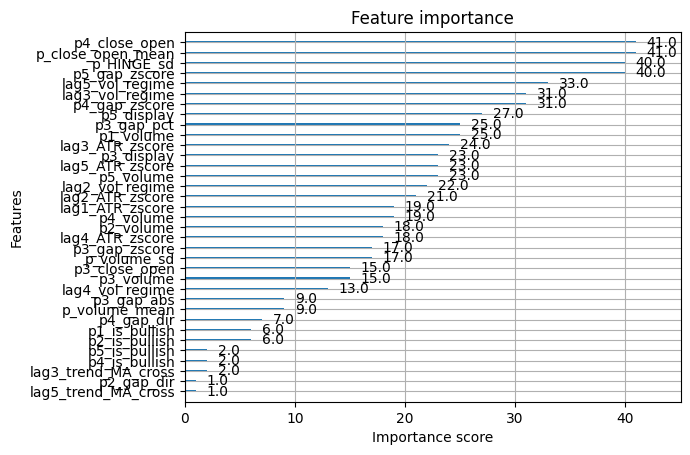

In [ ]:
# Importamos librerías necesarias
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Supongamos que ya tienes X y y
# Si aún no has hecho el split:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos el modelo XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,      # Número de árboles
    max_depth=3,           # Profundidad máxima de los árboles
    learning_rate=0.1,     # Tasa de aprendizaje
    objective='binary:logistic',  # Para clasificación binaria
    eval_metric='logloss'  # Métrica de evaluación
)

# Entrenamos el modelo
model.fit(X_train, y_train)

# Hacemos predicciones sobre el set de prueba
y_pred = model.predict(X_test)

# Evaluamos el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Si quieres, también puedes ver la importancia de las características
import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()


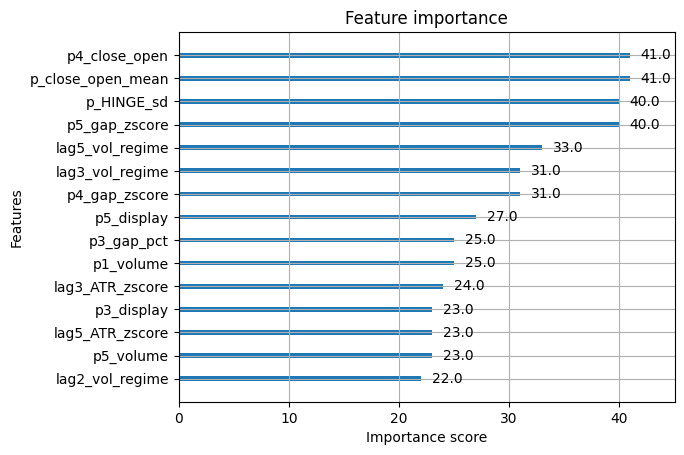

In [ ]:
xgb.plot_importance(model, max_num_features=15)
plt.show()

Random Forest

Accuracy: 0.5209

Confusion Matrix:
[[309 345]
 [285 376]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.47      0.50       654
           1       0.52      0.57      0.54       661

    accuracy                           0.52      1315
   macro avg       0.52      0.52      0.52      1315
weighted avg       0.52      0.52      0.52      1315



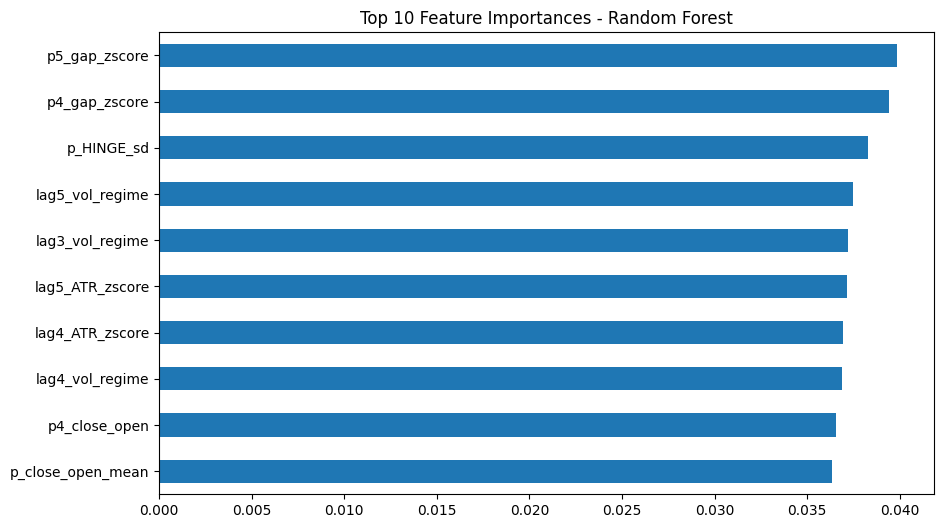

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

rf_model = RandomForestClassifier(
    n_estimators=200,    # Número de árboles
    max_depth=None,      # Crecimiento completo de árboles
    min_samples_split=2, # Número mínimo de muestras para dividir
    random_state=42,
    n_jobs=-1            # Usa todos los cores disponibles
)
rf_model.fit(X_train, y_train)

# Predicción
y_pred = rf_model.predict(X_test)

# Evaluación
print("Accuracy:", np.round(rf_model.score(X_test, y_test), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



# Importancia de features
importances = pd.Series(rf_model.feature_importances_, index=X_selected.columns)
importances = importances.sort_values(ascending=False)

# Mostrar top 10
plt.figure(figsize=(10,6))
importances[:10].plot(kind='barh')
top_10_features = importances.head(10).index.tolist()
plt.title("Top 10 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Entrenar Random Forest con las top 10
X_train_top10 = X_train[top_10_features]
X_test_top10 = X_test[top_10_features]
rf_model_top10 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model_top10.fit(X_train_top10, y_train)

y_pred = rf_model_top10.predict(X_test_top10)

print("\nAccuracy (Top 10 features):",
      np.round(rf_model_top10.score(X_test_top10, y_test), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy (Top 10 features): 0.5133

Confusion Matrix:
[[342 312]
 [328 333]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.52      0.52       654
           1       0.52      0.50      0.51       661

    accuracy                           0.51      1315
   macro avg       0.51      0.51      0.51      1315
weighted avg       0.51      0.51      0.51      1315



Varía solamente un 0.01 en las métricas al utilizar todos o sólo usar las 10 mejores. Considerar para cuando se implementen los datos de los minutos por la optimización del modelo.

Red Neuronal

Iteration 1, loss = 0.70717455
Validation score: 0.526616
Iteration 2, loss = 0.68863149
Validation score: 0.545627
Iteration 3, loss = 0.68445769
Validation score: 0.547529
Iteration 4, loss = 0.68038191
Validation score: 0.536122
Iteration 5, loss = 0.67700728
Validation score: 0.536122
Iteration 6, loss = 0.67303688
Validation score: 0.538023
Iteration 7, loss = 0.66975927
Validation score: 0.539924
Iteration 8, loss = 0.66532922
Validation score: 0.528517
Iteration 9, loss = 0.66095751
Validation score: 0.511407
Iteration 10, loss = 0.65624426
Validation score: 0.520913
Iteration 11, loss = 0.65092479
Validation score: 0.507605
Iteration 12, loss = 0.64505617
Validation score: 0.515209
Iteration 13, loss = 0.63985866
Validation score: 0.520913
Iteration 14, loss = 0.63311184
Validation score: 0.509506
Iteration 15, loss = 0.62655060
Validation score: 0.519011
Iteration 16, loss = 0.61918847
Validation score: 0.503802
Iteration 17, loss = 0.61224069
Validation score: 0.522814
Iterat

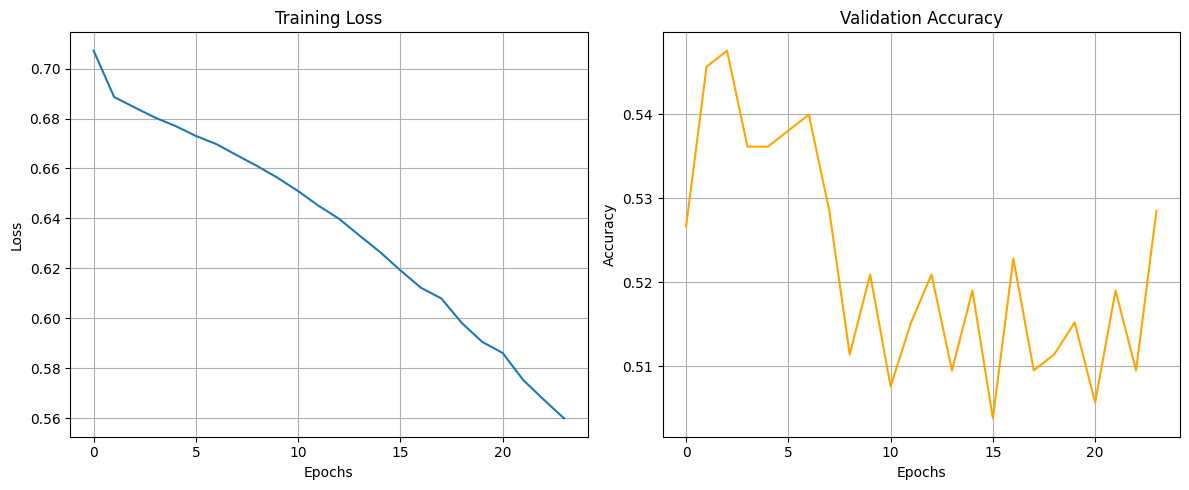

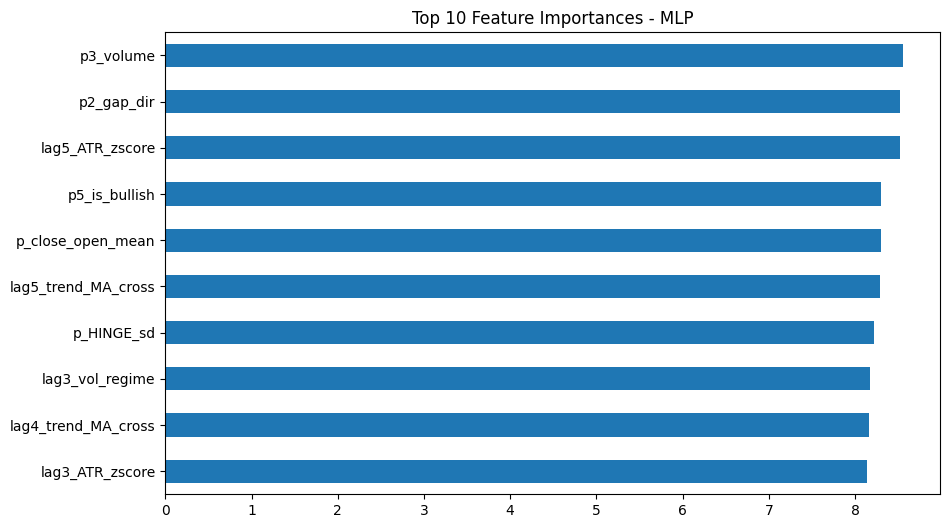

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar la red neuronal
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 32), # 2 capas ocultas
    activation='relu',
    solver='adam',
    alpha=0.001,                # regularización L2
    max_iter=750,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)
mlp_model.fit(X_train_scaled, y_train)

# Predicción
y_pred = mlp_model.predict(X_test_scaled)

# Evaluación
print("Accuracy:", np.round(mlp_model.score(X_test_scaled, y_test), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Gráfica de Loss y Accuracy en validación
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(mlp_model.loss_curve_, label='Training Loss')
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy en validación
plt.subplot(1,2,2)
plt.plot(mlp_model.validation_scores_, label='Validation Accuracy', color='orange')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

# Importancia aproximada de features usando pesos de la primera capa
importances = np.abs(mlp_model.coefs_[0]).sum(axis=1)
importances = pd.Series(importances, index=X_selected.columns).sort_values(ascending=False)

# Mostrar top 10 features
plt.figure(figsize=(10,6))
importances[:10].plot(kind='barh')
plt.title("Top 10 Feature Importances - MLP")
plt.gca().invert_yaxis()
plt.show()

Iteration 1, loss = 0.74270924
Validation score: 0.513308
Iteration 2, loss = 0.71217393
Validation score: 0.513308
Iteration 3, loss = 0.70051760
Validation score: 0.520913
Iteration 4, loss = 0.69720001
Validation score: 0.539924
Iteration 5, loss = 0.69608138
Validation score: 0.545627
Iteration 6, loss = 0.69550479
Validation score: 0.541825
Iteration 7, loss = 0.69506832
Validation score: 0.532319
Iteration 8, loss = 0.69466006
Validation score: 0.532319
Iteration 9, loss = 0.69430978
Validation score: 0.534221
Iteration 10, loss = 0.69396476
Validation score: 0.530418
Iteration 11, loss = 0.69366158
Validation score: 0.538023
Iteration 12, loss = 0.69335240
Validation score: 0.536122
Iteration 13, loss = 0.69308036
Validation score: 0.530418
Iteration 14, loss = 0.69279614
Validation score: 0.528517
Iteration 15, loss = 0.69249761
Validation score: 0.524715
Iteration 16, loss = 0.69225407
Validation score: 0.530418
Iteration 17, loss = 0.69205062
Validation score: 0.528517
Iterat

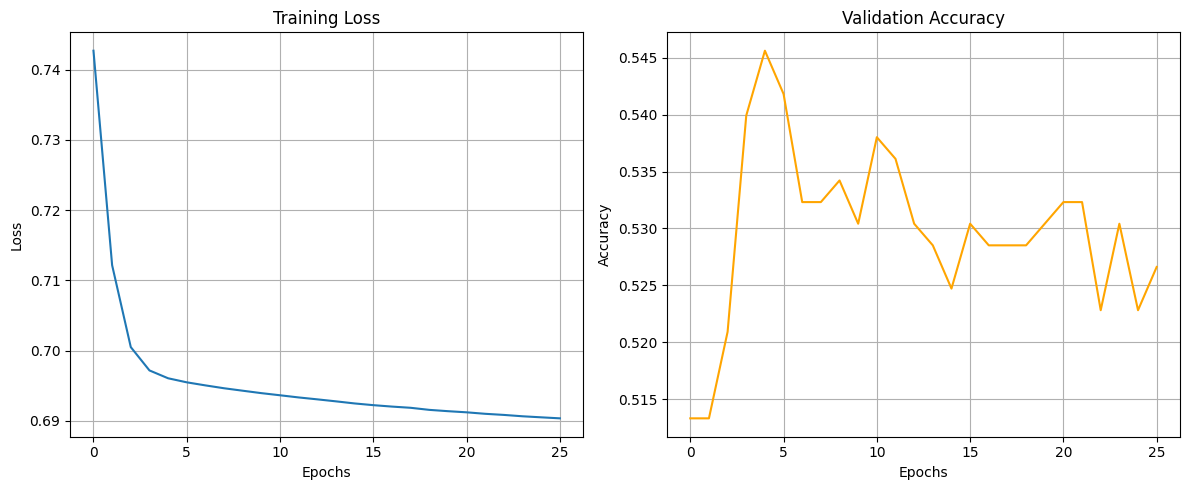

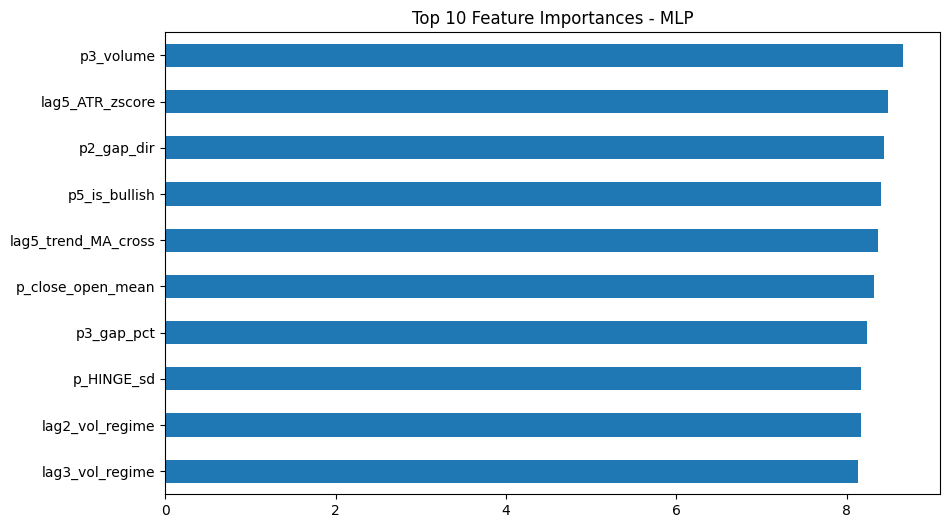

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar la red neuronal
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 32),
    activation='relu',
    solver='sgd',
    alpha=0.001,
    max_iter=750,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)
mlp_model.fit(X_train_scaled, y_train)

# Predicción
y_pred = mlp_model.predict(X_test_scaled)

# Evaluación
print("Accuracy:", np.round(mlp_model.score(X_test_scaled, y_test), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Gráfica de Loss y Accuracy en validación
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(mlp_model.loss_curve_, label='Training Loss')
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy en validación
plt.subplot(1,2,2)
plt.plot(mlp_model.validation_scores_, label='Validation Accuracy', color='orange')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()



# Importancia aproximada de features usando pesos de la primera capa
importances = np.abs(mlp_model.coefs_[0]).sum(axis=1)
importances = pd.Series(importances, index=X_selected.columns).sort_values(ascending=False)

# Mostrar top 10 features
plt.figure(figsize=(10,6))
importances[:10].plot(kind='barh')
plt.title("Top 10 Feature Importances - MLP")
plt.gca().invert_yaxis()
plt.show()

Iteration 1, loss = 0.74242039
Validation score: 0.513308
Iteration 2, loss = 0.71188548
Validation score: 0.513308
Iteration 3, loss = 0.70022898
Validation score: 0.520913
Iteration 4, loss = 0.69691142
Validation score: 0.539924
Iteration 5, loss = 0.69579283
Validation score: 0.545627
Iteration 6, loss = 0.69521629
Validation score: 0.541825
Iteration 7, loss = 0.69477991
Validation score: 0.532319
Iteration 8, loss = 0.69437178
Validation score: 0.532319
Iteration 9, loss = 0.69402168
Validation score: 0.534221
Iteration 10, loss = 0.69367677
Validation score: 0.530418
Iteration 11, loss = 0.69337346
Validation score: 0.538023
Iteration 12, loss = 0.69306436
Validation score: 0.536122
Iteration 13, loss = 0.69279228
Validation score: 0.530418
Iteration 14, loss = 0.69250781
Validation score: 0.528517
Iteration 15, loss = 0.69220930
Validation score: 0.524715
Iteration 16, loss = 0.69196576
Validation score: 0.530418
Iteration 17, loss = 0.69176240
Validation score: 0.528517
Iterat

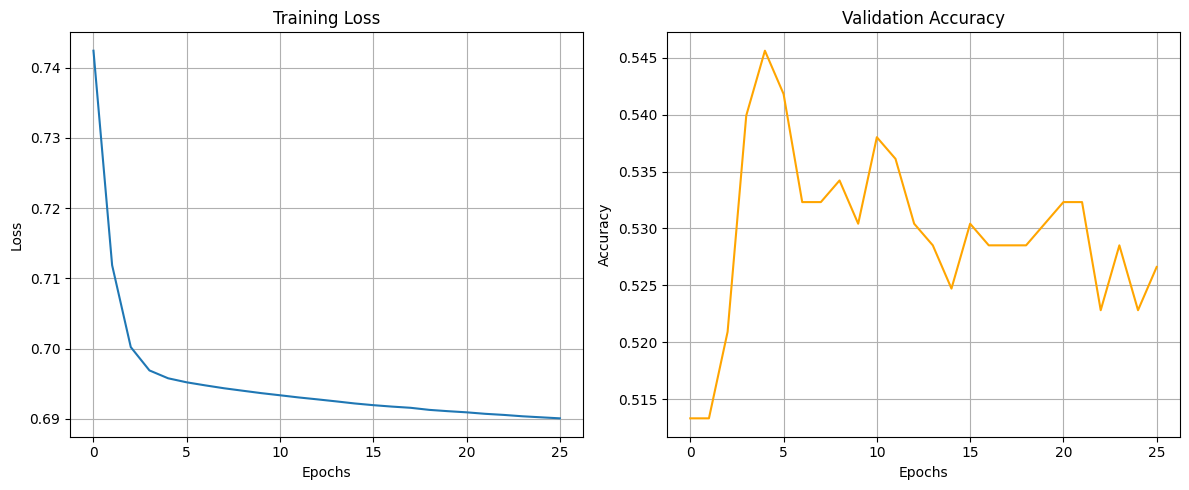

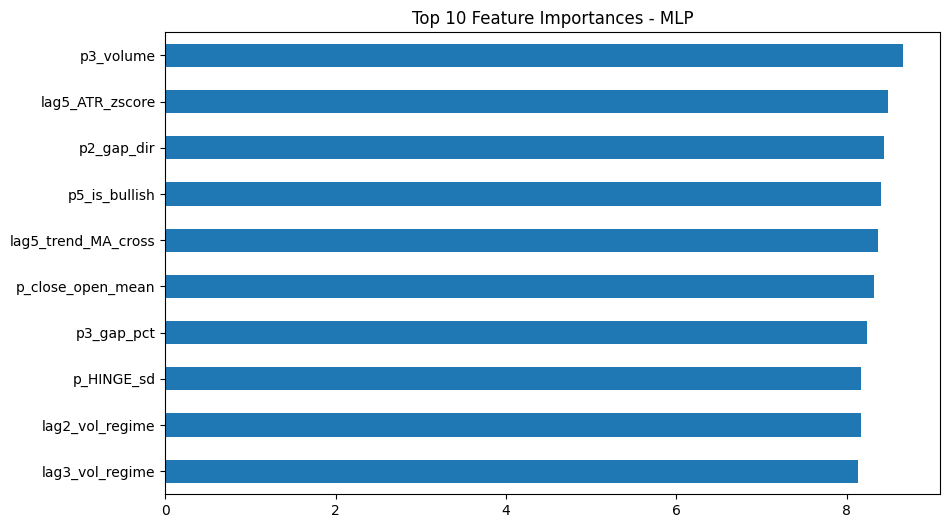

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar la red neuronal
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 32),
    activation='relu',
    solver='sgd',
    alpha=0.0001,
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)
mlp_model.fit(X_train_scaled, y_train)

# Predicción
y_pred = mlp_model.predict(X_test_scaled)

# Evaluación
print("Accuracy:", np.round(mlp_model.score(X_test_scaled, y_test), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Gráfica de Loss y Accuracy en validación
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(mlp_model.loss_curve_, label='Training Loss')
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy en validación
plt.subplot(1,2,2)
plt.plot(mlp_model.validation_scores_, label='Validation Accuracy', color='orange')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()



# Importancia aproximada de features usando pesos de la primera capa
importances = np.abs(mlp_model.coefs_[0]).sum(axis=1)
importances = pd.Series(importances, index=X_selected.columns).sort_values(ascending=False)

# Mostrar top 10 features
plt.figure(figsize=(10,6))
importances[:10].plot(kind='barh')
plt.title("Top 10 Feature Importances - MLP")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
print(importances.sort_values())

p3_is_bullish          6.853718
p3_gap_zscore          6.868997
p3_gap_abs             6.886089
p3_close_open          7.046448
p4_is_bullish          7.134023
p1_is_bullish          7.142271
p_volume_mean          7.338318
p5_display             7.345781
p5_gap_zscore          7.363759
lag5_vol_regime        7.372412
p2_volume              7.491070
p_volume_sd            7.503523
lag4_vol_regime        7.513829
lag4_ATR_zscore        7.516862
p3_gap_dir             7.530696
p5_volume              7.555439
lag1_trend_MA_cross    7.628168
lag2_trend_MA_cross    7.696835
lag1_ATR_zscore        7.728759
p3_display             7.757547
p1_volume              7.805517
lag3_trend_MA_cross    7.847032
p4_close_open          7.869770
p2_is_bullish          7.885815
p4_volume              7.943704
lag4_trend_MA_cross    8.015465
lag2_ATR_zscore        8.088495
p4_gap_dir             8.090184
p4_gap_zscore          8.097891
lag3_ATR_zscore        8.117928
lag3_vol_regime        8.129047
lag2_vol

In [ ]:
# Seleccionar top 15 variables
top15_vars = importances.sort_values(ascending=False).head(15).index

# Crear subconjunto de X
X_train_top15 = X_train[top15_vars]
X_test_top15  = X_test[top15_vars]

# Reentrenar XGBoost
import xgboost as xgb
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train_top15, y_train)

# Predicciones
y_pred = model.predict(X_test_top15)

# Métricas
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.51      0.52      0.51       654
           1       0.51      0.49      0.50       661

    accuracy                           0.51      1315
   macro avg       0.51      0.51      0.51      1315
weighted avg       0.51      0.51      0.51      1315



Iteration 1, loss = 0.69810679
Validation score: 0.501901
Iteration 2, loss = 0.69732870
Validation score: 0.517110
Iteration 3, loss = 0.69664950
Validation score: 0.517110
Iteration 4, loss = 0.69621665
Validation score: 0.509506
Iteration 5, loss = 0.69585339
Validation score: 0.511407
Iteration 6, loss = 0.69554768
Validation score: 0.513308
Iteration 7, loss = 0.69527480
Validation score: 0.509506
Iteration 8, loss = 0.69505399
Validation score: 0.505703
Iteration 9, loss = 0.69485297
Validation score: 0.519011
Iteration 10, loss = 0.69464824
Validation score: 0.507605
Iteration 11, loss = 0.69444208
Validation score: 0.515209
Iteration 12, loss = 0.69427296
Validation score: 0.513308
Iteration 13, loss = 0.69411838
Validation score: 0.509506
Iteration 14, loss = 0.69395164
Validation score: 0.511407
Iteration 15, loss = 0.69382507
Validation score: 0.511407
Iteration 16, loss = 0.69368957
Validation score: 0.513308
Iteration 17, loss = 0.69356308
Validation score: 0.509506
Iterat

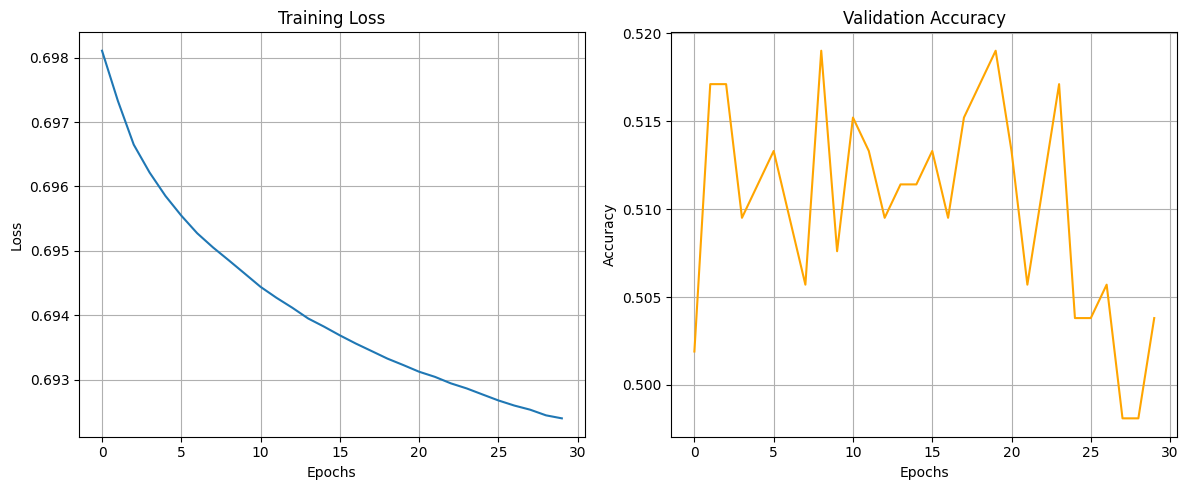

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top15)
X_test_scaled = scaler.transform(X_test_top15)

# Crear y entrenar la red neuronal
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 32), # 2 capas ocultas
    activation='relu',
    solver='sgd',
    alpha=0.0001,                # regularización L2
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)
mlp_model.fit(X_train_scaled, y_train)

# Predicción
y_pred = mlp_model.predict(X_test_scaled)

# Evaluación
print("Accuracy:", np.round(mlp_model.score(X_test_scaled, y_test), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Gráfica de Loss y Accuracy en validación
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(mlp_model.loss_curve_, label='Training Loss')
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy en validación
plt.subplot(1,2,2)
plt.plot(mlp_model.validation_scores_, label='Validation Accuracy', color='orange')
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


## Incluir df de minutos para hacer la comparativa y mejorar valores

Hay que unificar df_model con los minutos, para considerar a las 3.30 am como hora inicial para el primer minuto.

In [ ]:
df_dia = pd.read_csv(path+'/es1dia.txt')
df_dia['date'] = pd.to_datetime(df_dia['<DTYYYYMMDD>'], format='%Y%m%d')
df_dia = df_dia.sort_values('date').reset_index(drop=True)
df_dia.head()

,<TICKER>,<PER>,<DTYYYYMMDD>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>,date
0,ES,D,19970911,0,918.75,929.75,910.25,916.00,11825,2909,1997-09-11
1,ES,D,19970912,0,918.00,936.50,913.50,918.75,9759,4059,1997-09-12
2,ES,D,19970915,0,933.50,939.75,929.00,931.25,8551,3818,1997-09-15
3,ES,D,19970916,0,931.25,960.00,930.25,956.00,11749,5314,1997-09-16
4,ES,D,19970917,0,956.00,962.50,951.50,956.00,10849,5516,1997-09-17


In [ ]:
from datetime import time

df_min = df_es1min.copy()

df_min['datetime'] = pd.to_datetime(df_min['datetime'])
df_min['date'] = df_min['datetime'].dt.normalize()
df_min['time'] = df_min['datetime'].dt.time

# Filtrar ventana 03:30–03:44 y ordenar
df_open_mins = df_min[
    (df_min['time'] >= time(3, 30)) &
    (df_min['time'] <= time(3, 44))
].copy()
df_open_mins = (
    df_open_mins
    .sort_values(['date', 'datetime'])
    .assign(min_id=lambda x: x.groupby('date').cumcount() + 1)
)
df_open_mins.head()

,TICKER,PER,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,datetime,date,time
1133,ES,I,33000,2040.75,2041.00,2040.75,2041.00,15,0,2015-12-10 03:30:00,2015-12-10,03:30:00
1134,ES,I,33100,2041.00,2041.00,2041.00,2041.00,9,0,2015-12-10 03:31:00,2015-12-10,03:31:00
1135,ES,I,33200,2041.00,2041.25,2041.00,2041.25,14,0,2015-12-10 03:32:00,2015-12-10,03:32:00
1136,ES,I,33300,2041.25,2041.25,2041.25,2041.25,3,0,2015-12-10 03:33:00,2015-12-10,03:33:00
1137,ES,I,33400,2041.25,2041.50,2041.25,2041.25,39,0,2015-12-10 03:34:00,2015-12-10,03:34:00


In [ ]:
#Pivotar para tener formato diario
cols = [
    'date', 'min_id',
    'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL', 'OPENINT'
]
df_open_mins = df_open_mins[cols]
df_pivot = df_open_mins.pivot(
    index='date',
    columns='min_id',
    values=['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
)

# Aplanar columnas
df_pivot.columns = [
    f"m{min_id}_{var.lower()}"
    for var, min_id in df_pivot.columns
]

df_pivot = df_pivot.reset_index()
df_pivot

,date,m1_open,m2_open,m3_open,m4_open,m5_open,m6_open,m7_open,m8_open,m9_open,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,2015-12-10,2040.75,2041.00,2041.00,2041.25,2041.25,2041.50,2041.25,2041.00,2041.00,...,152.0,71.0,16.0,7.0,20.0,8.0,4.0,15.0,1.0,24.0
1,2015-12-11,2045.00,2045.25,2045.25,2045.50,2045.75,2045.75,2045.75,2045.75,2045.75,...,3.0,24.0,21.0,16.0,1.0,5.0,21.0,6.0,5.0,38.0
2,2015-12-14,2005.50,2005.25,2005.50,2005.50,2005.50,2005.00,2005.50,2005.50,2005.50,...,341.0,34.0,9.0,40.0,32.0,35.0,44.0,63.0,114.0,9.0
3,2015-12-15,2014.25,2014.50,2014.50,2014.50,2014.25,2014.50,2014.50,2014.50,2015.00,...,40.0,5.0,49.0,69.0,5.0,39.0,33.0,340.0,127.0,46.0
4,2015-12-16,2037.75,2037.75,2037.75,2037.75,2037.75,2038.00,2038.00,2038.50,2038.50,...,21.0,40.0,8.0,17.0,5.0,25.0,12.0,5.0,91.0,114.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1894,2023-09-14,4526.25,4526.25,4526.00,4526.00,4526.00,4525.75,4526.00,4525.25,4525.75,...,96.0,142.0,227.0,155.0,142.0,98.0,182.0,109.0,330.0,435.0
1895,2023-09-15,4558.00,4557.75,4557.00,4557.25,4557.50,4557.00,4557.00,4557.00,4557.00,...,111.0,168.0,91.0,177.0,105.0,121.0,102.0,213.0,127.0,198.0
1896,2023-09-18,4504.75,4504.75,4504.50,4504.00,4503.75,4504.00,4504.00,4503.75,4503.25,...,182.0,160.0,72.0,221.0,203.0,201.0,167.0,161.0,120.0,89.0
1897,2023-09-19,4501.75,4501.50,4501.50,4501.00,4501.25,4500.75,4500.75,4500.75,4501.25,...,151.0,161.0,230.0,83.0,172.0,236.0,133.0,143.0,95.0,70.0


In [ ]:
df_final = df_dia.merge(
    df_pivot,
    on='date',
    how='left'
)
df_final.head()

,<TICKER>,<PER>,<DTYYYYMMDD>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>,...,m6_vol,m7_vol,m8_vol,m9_vol,m10_vol,m11_vol,m12_vol,m13_vol,m14_vol,m15_vol
0,ES,D,19970911,0,918.75,929.75,910.25,916.00,11825,2909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ES,D,19970912,0,918.00,936.50,913.50,918.75,9759,4059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ES,D,19970915,0,933.50,939.75,929.00,931.25,8551,3818,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ES,D,19970916,0,931.25,960.00,930.25,956.00,11749,5314,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ES,D,19970917,0,956.00,962.50,951.50,956.00,10849,5516,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Columnas de minutos
cols_mins = [col for col in df_final.columns if col.startswith('m')]

# Crear columna temporal año
df_final['year'] = df_final['date'].dt.year

# Contar días con NaN por año
nan_summary = df_final.groupby('year').apply(
    lambda x: pd.Series({
        'total_dias': len(x),
        'dias_con_nan': x[cols_mins].isna().any(axis=1).sum(),
        'dias_completos': len(x) - x[cols_mins].isna().any(axis=1).sum()
    })
).reset_index()

print(nan_summary)


    year  total_dias  dias_con_nan  dias_completos
0   1997          78            78               0
1   1998         252           252               0
2   1999         252           252               0
3   2000         252           252               0
4   2001         249           249               0
5   2002         251           251               0
6   2003         254           254               0
7   2004         259           259               0
8   2005         258           258               0
9   2006         257           257               0
10  2007         259           259               0
11  2008         258           258               0
12  2009         257           257               0
13  2010         253           253               0
14  2011         252           252               0
15  2012         253           253               0
16  2013         252           252               0
17  2014         252           252               0
18  2015         254           

/tmp/ipython-input-3370402376.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_summary = df_final.groupby('year').apply(


No todos los años cuentan con valores de minutos. No podemos eliminar directamente los NaN porque entonces nos quedaríamos con pocos datos y sería poca muestra. Vamos a utilizar la siguiente estrategia:
- Para los modelos que soportan NaN-> mantener. Se va a mantener los Nan para modelos como XGBoost porque lo pueden soportar y así comprobamos.
- Para los modelos que no lo soportan -> Se reemplazará por la mediana. En caso de no obtener buenos resultados también se va a probar a eliminar las filas que tienen NaN.


Antes de llevar a cabo estas modificaciones es necesario implementar una transformación logarítmica para estandarizar la diferencia en la apertura y cierre. Si ha crecido mas de 0.25 sería bullish, si ha menguado más de 0.25 sería bearish y en el medio tierra de nadie.  